# 02 Почему рекурсивыне предсказания не работают

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PR = Path('./prediction_results')

btc_sum = pd.read_csv(PR / 'BTC-USD_prediction_summary.csv')
eth_sum = pd.read_csv(PR / 'ETH-USD_prediction_summary.csv')
val_sum = pd.read_csv(PR / 'BTC-USD_val_prediction_summary.csv')

cols = ['ticker', 'non_recursive_dir_acc', 'non_recursive_corr',
        'recursive_dir_acc', 'recursive_corr', 'final_price_error_pct']
summary = pd.concat([btc_sum.assign(split='test'),
                     eth_sum.assign(split='test'),
                     val_sum.assign(split='val')])[['split'] + cols].reset_index(drop=True)
summary.round(4)

,split,ticker,non_recursive_dir_acc,non_recursive_corr,recursive_dir_acc,recursive_corr,final_price_error_pct
0,test,BTC-USD,0.5228,0.2264,0.5172,-0.1386,2.8927
1,test,ETH-USD,0.5018,0.0835,0.5172,-0.2898,3.9383
2,val,BTC-USD,0.4677,0.0556,0.4333,0.2618,-11.1950


## Визуализация прогноза

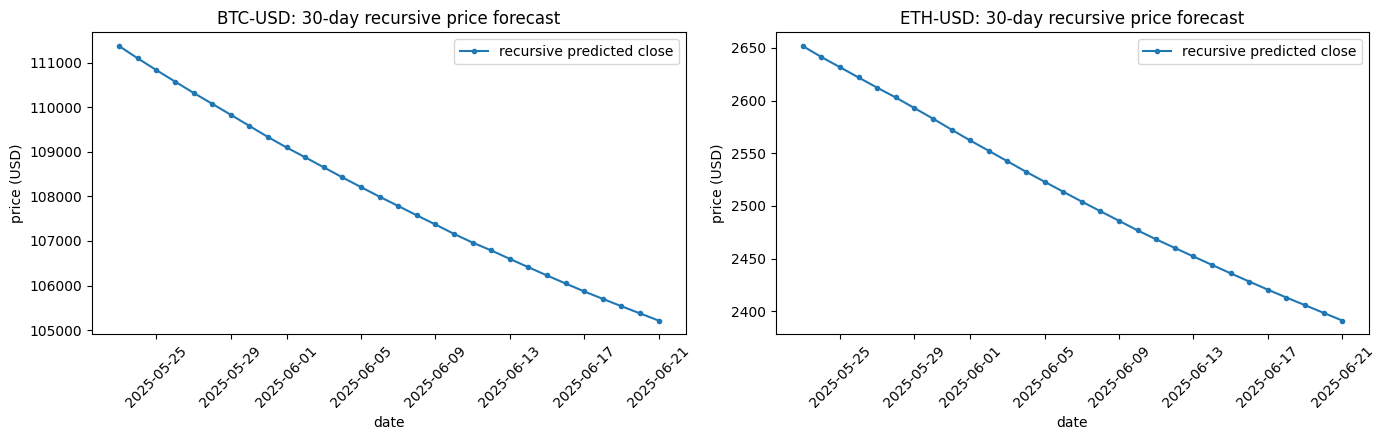

In [2]:
def load_path(name):
    df = pd.read_csv(PR / name, parse_dates=['date'])
    return df

btc = load_path('BTC-USD_full_recursive_predictions.csv')
eth = load_path('ETH-USD_full_recursive_predictions.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, df, name in [(axes[0], btc, 'BTC-USD'), (axes[1], eth, 'ETH-USD')]:
    ax.plot(df['date'], df['close'], marker='o', ms=3, label='recursive predicted close')
    ax.set_title(f'{name}: 30-day recursive price forecast')
    ax.set_xlabel('date'); ax.set_ylabel('price (USD)')
    ax.tick_params(axis='x', rotation=45); ax.legend()
plt.tight_layout(); plt.show()

## Графики directional accuracy и корреляции предсказаний с реальными данными

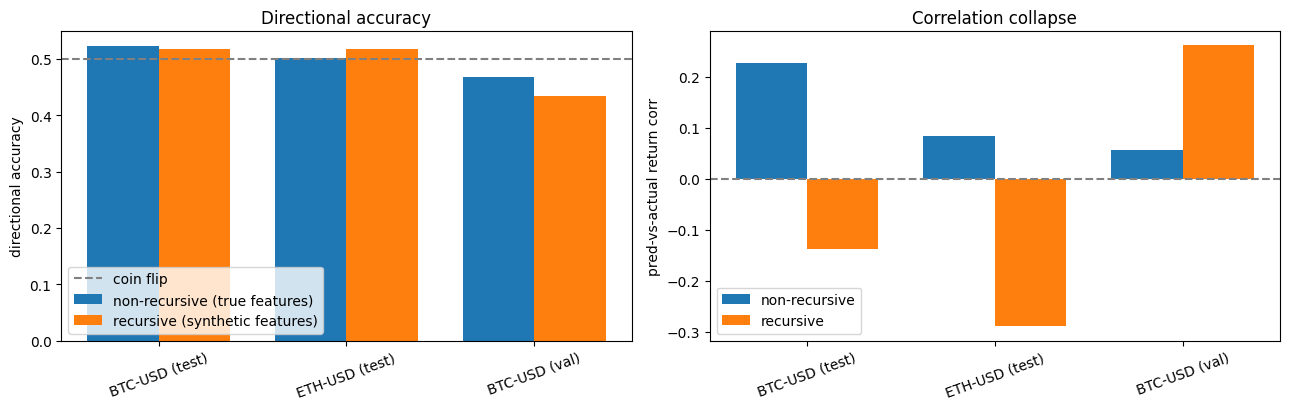

BTC-USD  test: corr +0.226 -> -0.139  |  final price error +2.89%
ETH-USD  test: corr +0.083 -> -0.290  |  final price error +3.94%
BTC-USD  val : corr +0.056 -> +0.262  |  final price error -11.19%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
labels = summary['ticker'] + ' (' + summary['split'] + ')'
x = np.arange(len(summary)); w = 0.38

axes[0].bar(x - w/2, summary['non_recursive_dir_acc'], w, label='non-recursive (true features)')
axes[0].bar(x + w/2, summary['recursive_dir_acc'],    w, label='recursive (synthetic features)')
axes[0].axhline(0.5, ls='--', c='gray', label='coin flip')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=20)
axes[0].set_ylabel('directional accuracy'); axes[0].set_title('Directional accuracy'); axes[0].legend()

axes[1].bar(x - w/2, summary['non_recursive_corr'], w, label='non-recursive')
axes[1].bar(x + w/2, summary['recursive_corr'],     w, label='recursive')
axes[1].axhline(0.0, ls='--', c='gray')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_ylabel('pred-vs-actual return corr'); axes[1].set_title('Correlation collapse'); axes[1].legend()
plt.tight_layout(); plt.show()

for _, r in summary.iterrows():
    print(f"{r['ticker']:8s} {r['split']:4s}: corr {r['non_recursive_corr']:+.3f} -> "
          f"{r['recursive_corr']:+.3f}  |  final price error {r['final_price_error_pct']:+.2f}%")

### Вывод
Предсказывать цену на 30 дней рекурсивно это неверная постановка задачи:
накопление ошибки гарантирует расхождение независимо от ёмкости модели.

Плюс предсказывать именно цену это тоже прлохо, так так мы будем сильно штрафовать модель (из за того что цена не стабильна и бывают больше скачки) и она будет выраждатся в то, чтобы предсказывать что цена не изменилась или какое-то константное значение